# ultra-mae Quickstart

End-to-end walk-through of MAE pretraining and linear probing on the
included synthetic ultrasound dataset.

**What this notebook does:**

1. Loads the example NPZ files and shows a few signals.
2. Pretrains the MAE on `data/pretrain.npz` (30 000 signals, signals only).
3. Plots the pretraining loss and visualizes a reconstruction.
4. Linear-probes the pretrained encoder on the `position` label
   (`data/probing.npz`, 3000 signals).
5. Plots predictions vs. ground truth on the held-out test set.

## Running on Colab

1. Open this notebook on Colab (the badge in the README does that for you).
2. Switch the runtime to GPU under **Runtime → Change runtime type**.
3. Run all cells. The first code cell clones the repo into the Colab runtime
   and `cd`s into `notebooks/`; everything else then works the same.

## 1. Setup

In [10]:
import os
import sys

REPO_URL = "https://github.com/immanuelrossteutscher/ultra-mae.git"
REPO_NAME = "ultra-mae"

if "google.colab" in sys.modules:
    REPO_ROOT = f"/content/{REPO_NAME}"
    if not os.path.isdir(REPO_ROOT):
        get_ipython().system(f"git clone {REPO_URL} {REPO_ROOT}")
    os.chdir(os.path.join(REPO_ROOT, "notebooks"))
else:
    # Walk up from CWD until we find the repo root (a dir containing src/ + config/).
    REPO_ROOT = None
    _cur = os.getcwd()
    while _cur != os.path.dirname(_cur):
        if all(os.path.isdir(os.path.join(_cur, d)) for d in ("src", "config")):
            REPO_ROOT = _cur
            break
        _cur = os.path.dirname(_cur)
    if REPO_ROOT is None:
        raise RuntimeError("Could not locate ultra-mae repo root.")

import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(REPO_ROOT, "src"))

BASE_DIR = REPO_ROOT
DATA_DIR = os.path.join(REPO_ROOT, "data")

print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Device: cuda


## 2. Inspect the data

In [11]:
from data import load_signals_npz

pre_signals, _ = load_signals_npz(os.path.join(DATA_DIR, "pretrain.npz"))
probe_signals, probe_labels = load_signals_npz(os.path.join(DATA_DIR, "probing.npz"))

print("pretrain.npz: signals", pre_signals.shape, pre_signals.dtype)
print("probing.npz:  signals", probe_signals.shape,
      "+ labels:", list(probe_labels.keys()))
print("position range:", probe_labels["position"].min(), "...",
      probe_labels["position"].max())

pretrain.npz: signals (30000, 512) float32
probing.npz:  signals (3000, 512) + labels: ['position']
position range: 0.09879775 ... 199.8544


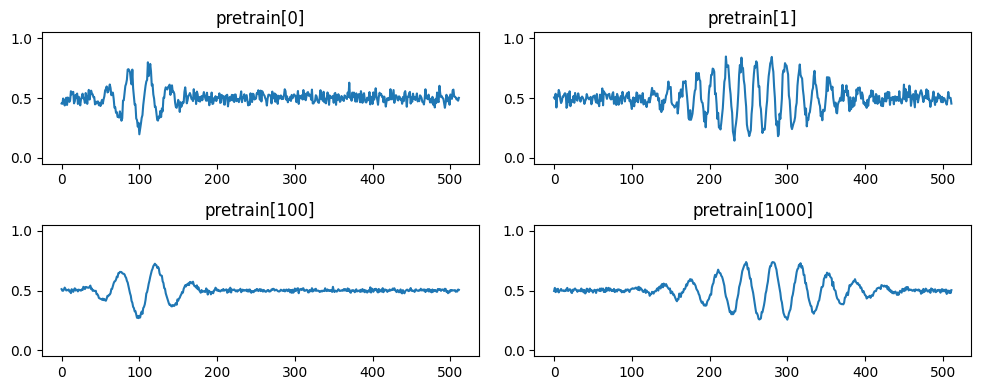

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), [0, 1, 100, 1000]):
    ax.plot(pre_signals[idx])
    ax.set_title(f"pretrain[{idx}]")
    ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 3. Pretrain the MAE

In [13]:
from train_pretrain import main as pretrain_main

with open(os.path.join(REPO_ROOT, "config", "pretrain.yaml")) as f:
    pre_cfg = yaml.safe_load(f)

pretrain_main(pre_cfg, BASE_DIR, DATA_DIR)

Device: cuda
Pretrain split: 24000/3000/3000
Encoder parameters: 1190656
Decoder parameters: 102304
MAE total params:   1308576
total_steps: 18400, warmup_steps: 2760
Config saved to: /content/ultra-mae/logs/pretrain/mae_pre_config.yaml
Epoch 000 | loss: 0.256245, mae: 0.476261 | val_loss: 0.217742, val_mae: 0.439146 | lr: 7.97e-06 | 1.1s
Epoch 001 | loss: 0.186065, mae: 0.404311 | val_loss: 0.154586, val_mae: 0.367017 | lr: 1.63e-05 | 1.0s
Epoch 002 | loss: 0.131977, mae: 0.336622 | val_loss: 0.110511, val_mae: 0.306551 | lr: 2.46e-05 | 1.0s
Epoch 003 | loss: 0.096501, mae: 0.284990 | val_loss: 0.082247, val_mae: 0.262566 | lr: 3.30e-05 | 0.9s
Epoch 004 | loss: 0.071026, mae: 0.242265 | val_loss: 0.058884, val_mae: 0.219306 | lr: 4.13e-05 | 0.9s
Epoch 005 | loss: 0.049287, mae: 0.198303 | val_loss: 0.039057, val_mae: 0.174949 | lr: 4.96e-05 | 1.1s
Epoch 006 | loss: 0.031546, mae: 0.154585 | val_loss: 0.023868, val_mae: 0.132530 | lr: 5.80e-05 | 1.0s
Epoch 007 | loss: 0.018927, mae: 0.

### Pretraining curves

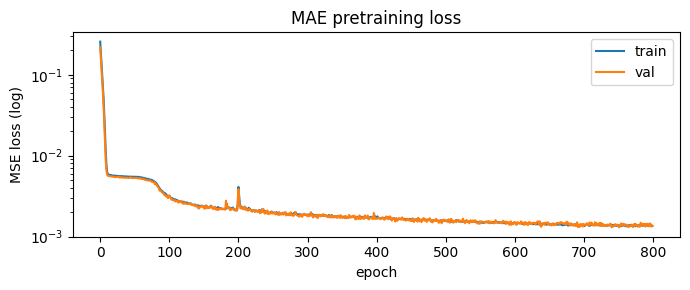

In [14]:
import csv

log_path = os.path.join(BASE_DIR, "logs", "pretrain", "mae_pre_log.csv")

with open(log_path) as f:
    rows = list(csv.DictReader(f))

epochs = [int(r["epoch"]) for r in rows]
train_loss = [float(r["loss"]) for r in rows]
val_loss = [float(r["val_loss"]) for r in rows]

plt.figure(figsize=(7, 3))
plt.plot(epochs, train_loss, label="train")
plt.plot(epochs, val_loss, label="val")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("MSE loss (log)"); plt.legend()
plt.title("MAE pretraining loss")
plt.tight_layout(); plt.show()


### Reconstruction example

Encoder parameters: 1190656
Decoder parameters: 102304
MAE total params:   1308576


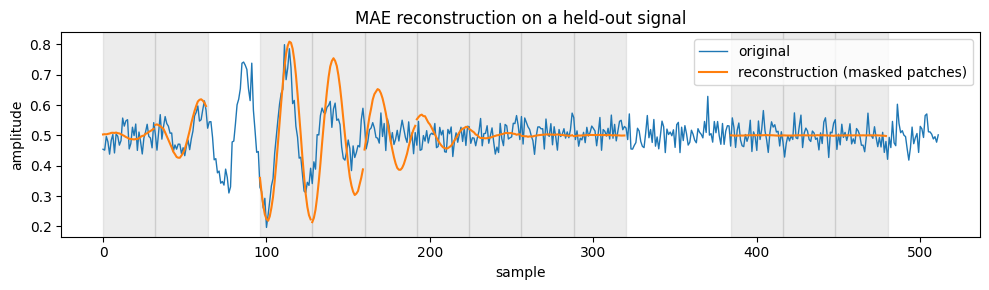

In [15]:
from model import build_mae_from_config

build_cfg = {**pre_cfg["model"],
             "mask_proportion": pre_cfg["pretrain"]["mask_proportion"],
             "dropout": 0.0}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mae = build_mae_from_config(build_cfg, device=device)
state = torch.load(os.path.join(BASE_DIR, "logs", "pretrain", "mae_pre.pth"),
                   map_location=device, weights_only=True)
mae.load_state_dict(state)
mae.eval()

torch.manual_seed(0)
x = torch.from_numpy(pre_signals[:1]).float().to(device)
with torch.no_grad():
    patches, pred_patches, mask_indices = mae.reconstruct(x)

patch_size = pre_cfg["model"]["patch_size"]
orig = patches[0].cpu().numpy().reshape(-1)
recon = pred_patches[0].cpu().numpy().reshape(-1)
masked = sorted(mask_indices[0].cpu().numpy().tolist())

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(orig, label="original", color="C0", lw=1.0)
for p in masked:
    start = p * patch_size
    ax.axvspan(start, start + patch_size, color="grey", alpha=0.15)
    ax.plot(range(start, start + patch_size),
            recon[start:start + patch_size],
            color="C1", lw=1.5)
ax.plot([], [], color="C1", lw=1.5, label="reconstruction (masked patches)")
ax.set_xlabel("sample"); ax.set_ylabel("amplitude")
ax.set_title("MAE reconstruction on a held-out signal")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()


## 4. Linear-probe on the position label

In [16]:
from train_downstream import main as downstream_main

with open(os.path.join(REPO_ROOT, "config", "linear_probe.yaml")) as f:
    lp_cfg = yaml.safe_load(f)

downstream_main(lp_cfg, BASE_DIR, DATA_DIR, factor_name="position")

Device: cuda
Task type: regression, output_dim: 1
Factor: position
Probing [position]: 1000/1000/1000
Encoder parameters: 1190656
Decoder parameters: 102304
MAE total params:   1308576
Pretrained weights loaded from: /content/ultra-mae/logs/pretrain/mae_pre.pth
Steps/epoch: 8, total: 240, warmup: 24
Config saved to: /content/ultra-mae/logs/probing/mae_position_lp_config.yaml
Epoch 000 | loss: 11450.719281, R²: -2.6104, MAE: 92.6379 | val_loss: 10142.207430, val_R²: -2.3569, val_MAE: 89.8947 | 0.1s
Epoch 001 | loss: 8516.883773, R²: -1.6854, MAE: 87.1933 | val_loss: 6112.396160, val_R²: -1.0231, val_MAE: 75.3668 | 0.1s
Epoch 002 | loss: 5984.030352, R²: -0.8868, MAE: 72.8312 | val_loss: 3564.602002, val_R²: -0.1798, val_MAE: 56.7716 | 0.1s
Epoch 003 | loss: 3113.405396, R²: 0.0183, MAE: 52.3086 | val_loss: 1779.923026, val_R²: 0.4109, val_MAE: 39.0648 | 0.1s
Epoch 004 | loss: 1393.121010, R²: 0.5607, MAE: 33.9615 | val_loss: 803.372566, val_R²: 0.7341, val_MAE: 25.0273 | 0.1s
Epoch 005 

### Probing curves and predictions

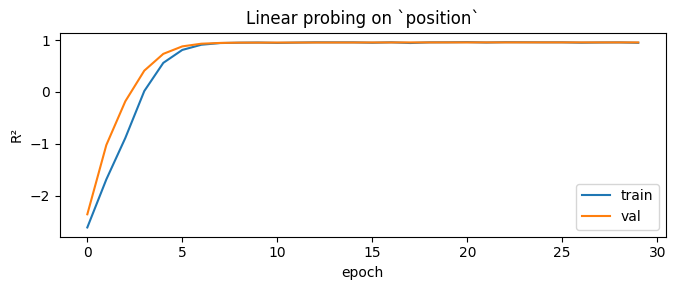

In [17]:
log_path = os.path.join(BASE_DIR, "logs", "probing", "mae_position_lp_log.csv")
with open(log_path) as f:
    rows = list(csv.DictReader(f))

epochs = [int(r["epoch"]) for r in rows]
train_r2 = [float(r["r2"]) for r in rows]
val_r2 = [float(r["val_r2"]) for r in rows]

plt.figure(figsize=(7, 3))
plt.plot(epochs, train_r2, label="train")
plt.plot(epochs, val_r2, label="val")
plt.xlabel("epoch"); plt.ylabel("R²"); plt.legend()
plt.title("Linear probing on `position`")
plt.tight_layout(); plt.show()

Probing [position]: 1000/1000/1000
Encoder parameters: 1190656
Decoder parameters: 102304
MAE total params:   1308576


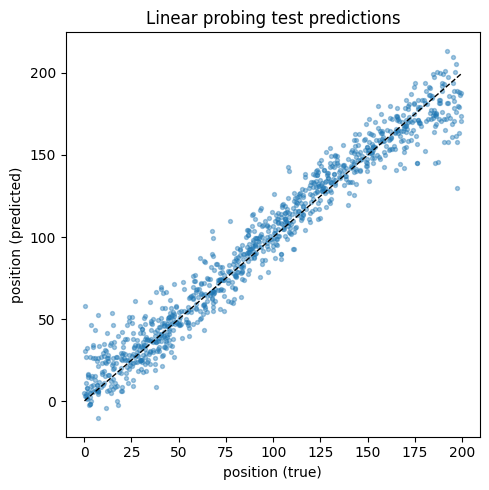

In [18]:
from data import load_and_split_probing
from model import build_mae_from_config, build_downstream_from_mae

(_, _), (_, _), (x_test, y_test) = load_and_split_probing(
    os.path.join(DATA_DIR, "probing.npz"), "position",
    split=lp_cfg["downstream"]["split"], seed=lp_cfg["downstream"]["split_seed"],
)

mae = build_mae_from_config(build_cfg, device=device)
ds_model = build_downstream_from_mae(
    mae, 1, pre_cfg["model"], device=device,
    finetune_strategy=lp_cfg["downstream"]["finetune_strategy"],
    downstream_dropout=lp_cfg["downstream"]["dropout"],
    head_dropout=lp_cfg["downstream"]["head_dropout"],
    train_patch_encoder=lp_cfg["downstream"]["train_patch_encoder"],
)
ds_state = torch.load(os.path.join(BASE_DIR, "logs", "probing", "mae_position_lp.pth"),
                      map_location=device, weights_only=True)
ds_model.load_state_dict(ds_state)
ds_model.eval()

with torch.no_grad():
    x = torch.from_numpy(x_test).float().to(device)
    y_pred = ds_model(x).squeeze(-1).cpu().numpy()

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, s=8, alpha=0.4)
lo, hi = float(y_test.min()), float(y_test.max())
plt.plot([lo, hi], [lo, hi], "k--", lw=1)
plt.xlabel("position (true)"); plt.ylabel("position (predicted)")
plt.title("Linear probing test predictions")
plt.tight_layout(); plt.show()
